# Time Series Forecasting - Sales predicting

En este ejercicio intentare predecir el volumen de ventas, para poder preveer el espacio de almacenamiento necesario en los proximos meses.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv'

df = pd.read_csv(url)

df.to_csv('../data/raw/data.csv')

In [3]:
df.shape

(366, 2)

In [4]:
df.sample(5)

,date,sales
187,2023-03-09 17:10:08.079328,536.868824
1,2022-09-04 17:10:08.079328,53.803211
332,2023-08-01 17:10:08.079328,916.429348
362,2023-08-31 17:10:08.079328,994.987326
334,2023-08-03 17:10:08.079328,911.337552


Limpio las fechas de mis datos

In [5]:
import pandas as pd

df['date'] = pd.to_datetime(df['date'])  # Cambio el tipo de dato a datetime

df.set_index('date', inplace=True)

df.sample(5)

,sales
date,
2023-05-26 17:10:08.079328,740.292363
2023-06-17 17:10:08.079328,800.619737
2023-06-08 17:10:08.079328,767.469590
2023-01-15 17:10:08.079328,396.859585
2023-03-11 17:10:08.079328,546.546852


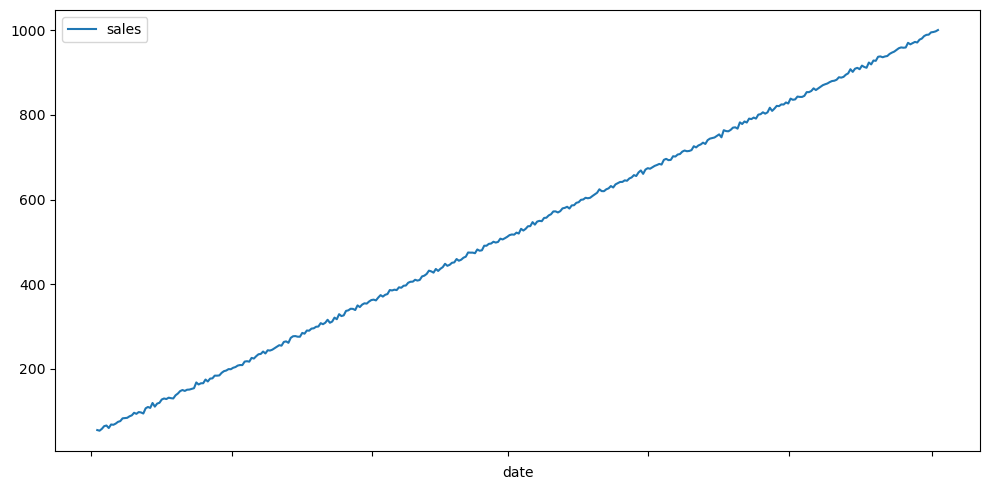

In [6]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)

axis.set_xticklabels([])

plt.tight_layout()

plt.show()

## Descomposición de la serie


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df, period = 52) # Periodo semanal

## Análisis de la tendencia

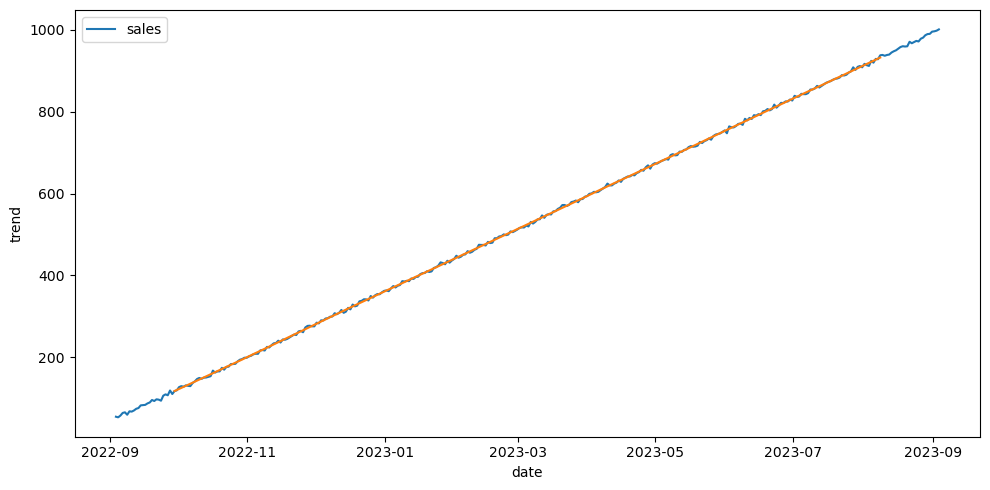

In [8]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = trend)


plt.tight_layout()

plt.show()

Se confirma una clara tendencia al alza de manera lineal a lo largo del tiempo

## Análisis de la estacionalidad


In [9]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

Dado que el p-value es superior a 0.05 descartaremos la hipotesis nula. Esto significa que la serie no es estacionaria.

## Análisis de la variabilidad


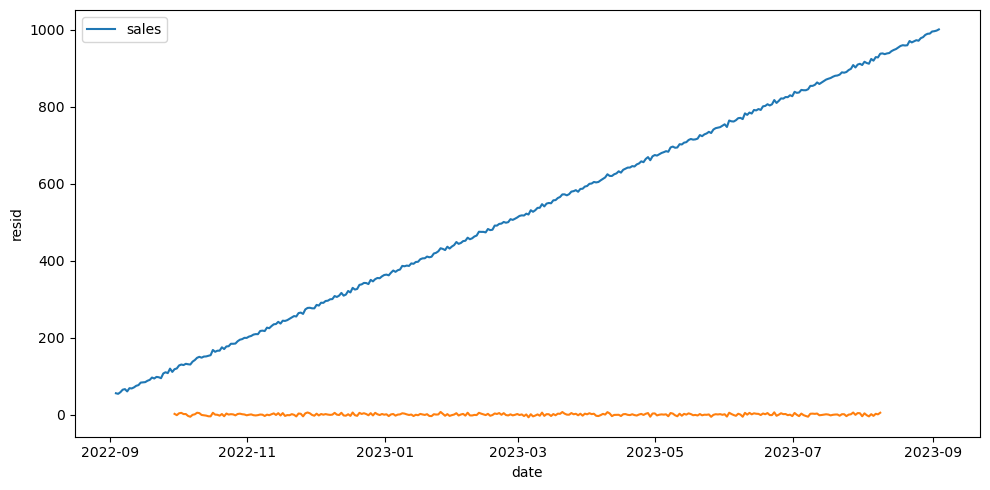

In [10]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

## Análisis de la autocorrelación¶


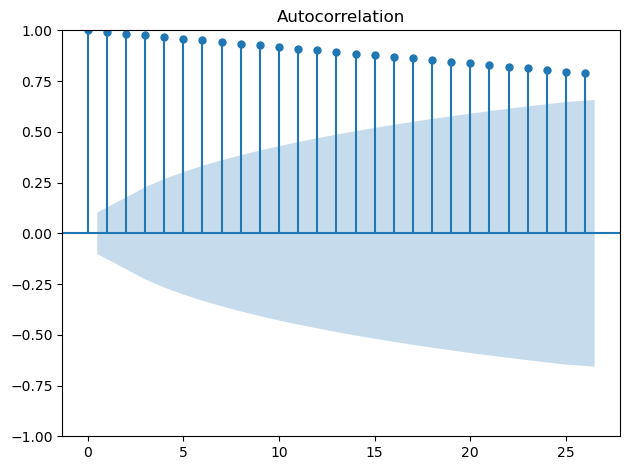

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df)

plt.tight_layout()

plt.show()

## Entrenamiento del modelo

In [12]:
from pmdarima import auto_arima

model = auto_arima(df, seasonal = True, trace = True, m = 12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1847.125, Time=0.81 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1972.853, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2209.657, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=1844.714, Time=0.72 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=1843.204, Time=0.32 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=1845.092, Time=0.62 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=1843.586, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=1841.532, Time=0.24 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=1843.435, Time=0.70 sec
 ARIMA(2,1,1)(0,0,1)[12] intercept   : AIC=1843.433, Time=0.65 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=1.01 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1839.552, Time=0.13 sec
 ARIMA(1,1,1)(1,0,0)[12] inte

In [17]:
forecast = model.predict(100)
forecast

2023-09-04 17:10:08.079328    1002.158148
2023-09-05 17:10:08.079328    1004.831669
2023-09-06 17:10:08.079328    1007.423289
2023-09-07 17:10:08.079328    1010.021630
2023-09-08 17:10:08.079328    1012.619419
                                 ...     
2023-12-08 17:10:08.079328    1249.022047
2023-12-09 17:10:08.079328    1251.619878
2023-12-10 17:10:08.079328    1254.217709
2023-12-11 17:10:08.079328    1256.815540
2023-12-12 17:10:08.079328    1259.413371
Freq: D, Length: 100, dtype: float64

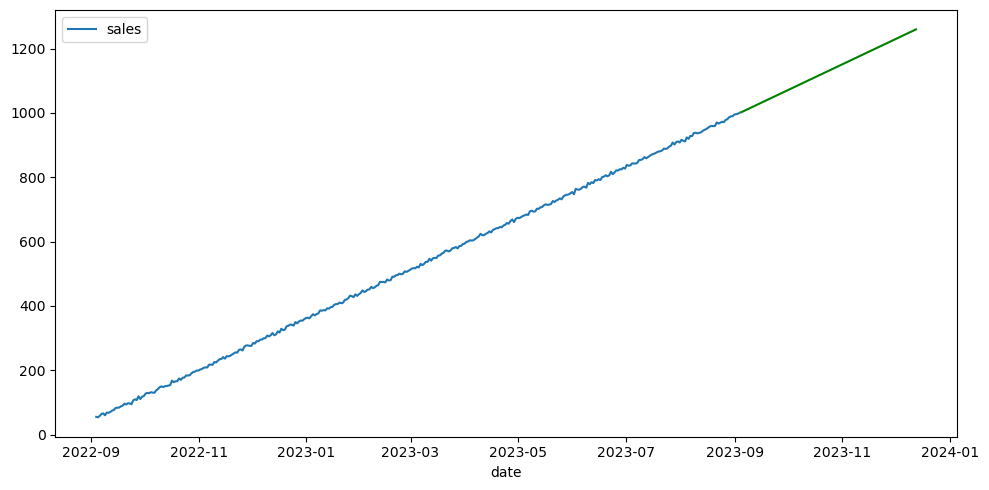

In [18]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()